# DSF Lab Exam Prep: Campus Events (Sample HTML)
Covers: the sample file, the "likely questions", **Mock Question 1** (full pipeline) and **Mock Question 3** (analysis).

Pipeline: **HTML → JSON → DataFrame → cleaning → features → Min-Max → analysis → plots → CSV**

Keep `HTML_Reference_Sample_Campus_Events.html` in the same folder as this notebook.

## 1. Imports

In [1]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

## 2. HTML → JSON (semi-structured)
`get_text()` is the safe-extraction helper. If a tag is missing (like the venue in the last event) it returns `None` instead of crashing.

In [2]:
HTML_FILE = "HTML_Reference_Sample_Campus_Events.html"

with open(HTML_FILE, encoding="utf-8") as f:
    soup = BeautifulSoup(f, "html.parser")

def get_text(parent, selector):
    el = parent.select_one(selector)
    return el.get_text(strip=True) if el else None

events = []
for div in soup.find_all("div", class_="event"):
    events.append({
        "name":     get_text(div, "h2"),
        "venue":    get_text(div, "p.venue"),
        "date":     get_text(div, "p.date"),
        "category": get_text(div, "span.category"),
        "fee":      get_text(div, "span.fee"),
        "seats":    get_text(div, "p.seats"),
    })

print("Events found:", len(events))
print(json.dumps(events[:7], indent=4, ensure_ascii=False))

Events found: 7
[
    {
        "name": "Photography Walk",
        "venue": "Central Park",
        "date": "12 October 2026",
        "category": "Hobby",
        "fee": "₹100",
        "seats": "Seats: 30"
    },
    {
        "name": "Python Workshop",
        "venue": "Computer Lab 2",
        "date": "15 October 2026",
        "category": "Technical",
        "fee": "₹250",
        "seats": "Seats: 45"
    },
    {
        "name": "Inter-College Quiz",
        "venue": "Seminar Hall",
        "date": "18 October 2026",
        "category": "Competition",
        "fee": "₹50",
        "seats": "Seats: 80"
    },
    {
        "name": "Film Appreciation Session",
        "venue": "Auditorium",
        "date": "21 October 2026",
        "category": "Cultural",
        "fee": "Free",
        "seats": "Seats: 120"
    },
    {
        "name": "Robotics Demonstration",
        "venue": "Innovation Lab",
        "date": "24 October 2026",
        "category": "Technical",
        "fee": "

In [3]:
# Save as JSON file, then read it back (semi-structured stage)
with open("events.json", "w", encoding="utf-8") as f:
    json.dump(events, f, indent=4, ensure_ascii=False)

with open("events.json", encoding="utf-8") as f:
    data = json.load(f)

## 3. JSON → Pandas DataFrame (structured)

In [4]:
df = pd.DataFrame(data)
df

,name,venue,date,category,fee,seats
0,Photography Walk,Central Park,12 October 2026,Hobby,₹100,Seats: 30
1,Python Workshop,Computer Lab 2,15 October 2026,Technical,₹250,Seats: 45
2,Inter-College Quiz,Seminar Hall,18 October 2026,Competition,₹50,Seats: 80
3,Film Appreciation Session,Auditorium,21 October 2026,Cultural,Free,Seats: 120
4,Robotics Demonstration,Innovation Lab,24 October 2026,Technical,₹150,Seats: 25
5,Open Mic Evening,Student Activity Centre,27 October 2026,Cultural,₹80,Seats: 60
6,Career Guidance Talk,NaN,30 October 2026,Career,Free,Seats: 100


In [5]:
df.info()
print()
print("Missing values:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   name      7 non-null      str  
 1   venue     6 non-null      str  
 2   date      7 non-null      str  
 3   category  7 non-null      str  
 4   fee       7 non-null      str  
 5   seats     7 non-null      str  
dtypes: str(6)
memory usage: 468.0 bytes

Missing values:
name        0
venue       1
date        0
category    0
fee         0
seats       0
dtype: int64


## 4. Data wrangling
Steps: missing values → duplicates → text formats → data types.

In [6]:
# 4.1 Missing values: venue is missing for the last event
df["venue"] = df["venue"].fillna("Not Specified")

# 4.2 Duplicates
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

# 4.3 Text formatting
for col in ["name", "venue", "category"]:
    df[col] = df[col].str.strip().str.title()

Duplicates before: 0


In [7]:
#money

import re
import numpy as np
import pandas as pd

def clean_money(value):
    if pd.isna(value):
        return np.nan

    s = str(value).strip().lower()

    # Free / zero / missing
    if s in ["free", "gratis", "no fee", "no cost", "0"]:
        return 0.0

    if s in ["", "na", "n/a", "none", "null", "-", "--", "not available"]:
        return np.nan

    # Remove currency symbols and spaces
    s = s.replace(",", "").replace("₹", "").replace("$", "")
    s = s.replace("€", "").replace("£", "").replace("¥", "")
    s = re.sub(r"\b(inr|rs|rs\.|usd|eur|gbp)\b", "", s)

    # Crore
    match = re.search(r"([\d.]+)\s*(crore|cr)\b", s)
    if match:
        return float(match.group(1)) * 10_000_000

    # Lakh
    match = re.search(r"([\d.]+)\s*(lakh|lakhs|lac|lacs|l)\b", s)
    if match:
        return float(match.group(1)) * 100_000

    # Million
    match = re.search(r"([\d.]+)\s*(million|m)\b", s)
    if match:
        return float(match.group(1)) * 1_000_000

    # Thousand / K
    match = re.search(r"([\d.]+)\s*(thousand|k)\b", s)
    if match:
        return float(match.group(1)) * 1_000

    # Normal number
    match = re.search(r"\d+(?:\.\d+)?", s)
    if match:
        return float(match.group())

    return np.nan

In [8]:
# 4.4 Data types

# Fee: remove the rupee symbol and commas, treat 'Free' as 0
df["fee"] = df["fee"].apply(clean_money)

# Seats: 'Seats: 30' -> 30
df["seats"] = df["seats"].str.extract(r"(\d+)")[0].astype(int)

# Date: '12 October 2026' -> datetime
df["date"] = pd.to_datetime(df["date"], format="%d %B %Y")

# Date parts
df["weekday"] = df["date"].dt.day_name()
df["month"]   = df["date"].dt.month_name()

df.dtypes

name                   str
venue                  str
date        datetime64[us]
category               str
fee                float64
seats                int64
weekday                str
month                  str
dtype: object

## 5. Feature engineering (new columns)
- `is_free`: True if fee is 0
- `fee_category`: Free / Low / Medium / High
- `revenue_potential`: fee × seats
- `name_length`: number of characters in the name
- `days_left`: days between a reference date and the event

In [9]:
REF_DATE = pd.Timestamp("2026-10-01")   # change if the question gives a different reference date

df["is_free"] = df["fee"] == 0
df["fee_category"] = pd.cut(df["fee"], bins=[-1, 0, 100, 200, float("inf")],
                            labels=["Free", "Low", "Medium", "High"])
df["revenue_potential"] = df["fee"] * df["seats"]
df["name_length"] = df["name"].str.len()
df["days_left"] = (df["date"] - REF_DATE).dt.days

df

,name,venue,date,category,fee,seats,weekday,month,is_free,fee_category,revenue_potential,name_length,days_left
0,Photography Walk,Central Park,2026-10-12,Hobby,100.0,30,Monday,October,False,Low,3000.0,16,11
1,Python Workshop,Computer Lab 2,2026-10-15,Technical,250.0,45,Thursday,October,False,High,11250.0,15,14
2,Inter-College Quiz,Seminar Hall,2026-10-18,Competition,50.0,80,Sunday,October,False,Low,4000.0,18,17
3,Film Appreciation Session,Auditorium,2026-10-21,Cultural,0.0,120,Wednesday,October,True,Free,0.0,25,20
4,Robotics Demonstration,Innovation Lab,2026-10-24,Technical,150.0,25,Saturday,October,False,Medium,3750.0,22,23
5,Open Mic Evening,Student Activity Centre,2026-10-27,Cultural,80.0,60,Tuesday,October,False,Low,4800.0,16,26
6,Career Guidance Talk,Not Specified,2026-10-30,Career,0.0,100,Friday,October,True,Free,0.0,20,29


## 6. Min-Max normalization
Formula: `x_norm = (x - min) / (max - min)`, which scales values to the range 0 to 1.

**Justification:** `fee` (0 to 250) and `seats` (25 to 120) are on different scales. Min-Max puts them on the same 0-1 scale so one feature does not dominate the other in distance-based analysis or ML models (KNN, K-Means), and it keeps the original shape of the distribution.

In [10]:
# Manual formula (write this one in the exam)
df["fee_norm"] = (df["fee"] - df["fee"].min()) / (df["fee"].max() - df["fee"].min())
df["seats_norm"] = (df["seats"] - df["seats"].min()) / (df["seats"].max() - df["seats"].min())

# Same thing with sklearn (optional check)
from sklearn.preprocessing import MinMaxScaler
check = MinMaxScaler().fit_transform(df[["fee"]]).ravel()
print("Manual matches sklearn:", np.allclose(check, df["fee_norm"]))

df[["name", "fee", "fee_norm", "seats", "seats_norm"]]

Manual matches sklearn: True


,name,fee,fee_norm,seats,seats_norm
0,Photography Walk,100.0,0.40,30,0.052632
1,Python Workshop,250.0,1.00,45,0.210526
2,Inter-College Quiz,50.0,0.20,80,0.578947
3,Film Appreciation Session,0.0,0.00,120,1.000000
4,Robotics Demonstration,150.0,0.60,25,0.000000
5,Open Mic Evening,80.0,0.32,60,0.368421
6,Career Guidance Talk,0.0,0.00,100,0.789474


## 7. Likely questions (analysis)

In [11]:
print("Highest fee event:")
print(df.loc[df["fee"].idxmax(), ["name", "fee"]].to_string(), "\n")

print("Most seats event:")
print(df.loc[df["seats"].idxmax(), ["name", "seats"]].to_string(), "\n")

print("Highest revenue potential event:")
print(df.loc[df["revenue_potential"].idxmax(), ["name", "revenue_potential"]].to_string())

Highest fee event:
name    Python Workshop
fee               250.0 

Most seats event:
name     Film Appreciation Session
seats                          120 

Highest revenue potential event:
name                 Python Workshop
revenue_potential            11250.0


In [12]:
# Number of events per category
print(df["category"].value_counts(), "\n")

# Average fee per category
print(df.groupby("category")["fee"].mean().round(2))

category
Technical      2
Cultural       2
Hobby          1
Competition    1
Career         1
Name: count, dtype: int64 

category
Career           0.0
Competition     50.0
Cultural        40.0
Hobby          100.0
Technical      200.0
Name: fee, dtype: float64


In [13]:
# Filtering
print("Only Technical events:")
display(df[df["category"] == "Technical"][["name", "venue", "fee", "seats"]])

print("Events with fee below 100:")
display(df[df["fee"] < 100][["name", "fee"]])

print("Free events:")
display(df[df["is_free"]][["name", "category"]])

Only Technical events:


,name,venue,fee,seats
1,Python Workshop,Computer Lab 2,250.0,45
4,Robotics Demonstration,Innovation Lab,150.0,25


Events with fee below 100:


,name,fee
2,Inter-College Quiz,50.0
3,Film Appreciation Session,0.0
5,Open Mic Evening,80.0
6,Career Guidance Talk,0.0


Free events:


,name,category
3,Film Appreciation Session,Cultural
6,Career Guidance Talk,Career


## 8. Mock Question 3: Analysis on the cleaned DataFrame
**a.** Events with fee below ₹100 and seats above 50

In [14]:
df[(df["fee"] < 100) & (df["seats"] > 50)][["name", "fee", "seats"]]

,name,fee,seats
2,Inter-College Quiz,50.0,80
3,Film Appreciation Session,0.0,120
5,Open Mic Evening,80.0,60
6,Career Guidance Talk,0.0,100


**b.** Group by category: number of events, average fee, total seats

In [15]:
summary = df.groupby("category").agg(
    num_events=("name", "count"),
    avg_fee=("fee", "mean"),
    total_seats=("seats", "sum"),
    total_revenue=("revenue_potential", "sum")
).round(2)
summary

,num_events,avg_fee,total_seats,total_revenue
category,,,,
Career,1,0.0,100,0.0
Competition,1,50.0,80,4000.0
Cultural,2,40.0,180,4800.0
Hobby,1,100.0,30,3000.0
Technical,2,200.0,70,15000.0


**c.** Event with highest potential revenue, and category with highest total revenue

In [16]:
top_event = df.loc[df["revenue_potential"].idxmax()]
print("Top event:", top_event["name"], "| Revenue:", top_event["revenue_potential"])

top_cat = summary["total_revenue"].idxmax()
print("Top category:", top_cat, "| Revenue:", summary.loc[top_cat, "total_revenue"])

Top event: Python Workshop | Revenue: 11250.0
Top category: Technical | Revenue: 15000.0


**d.** `days_left` from a reference date, sorted

In [17]:
df.sort_values("days_left")[["name", "date", "days_left"]]

,name,date,days_left
0,Photography Walk,2026-10-12,11
1,Python Workshop,2026-10-15,14
2,Inter-College Quiz,2026-10-18,17
3,Film Appreciation Session,2026-10-21,20
4,Robotics Demonstration,2026-10-24,23
5,Open Mic Evening,2026-10-27,26
6,Career Guidance Talk,2026-10-30,29


## 9. Visualizations

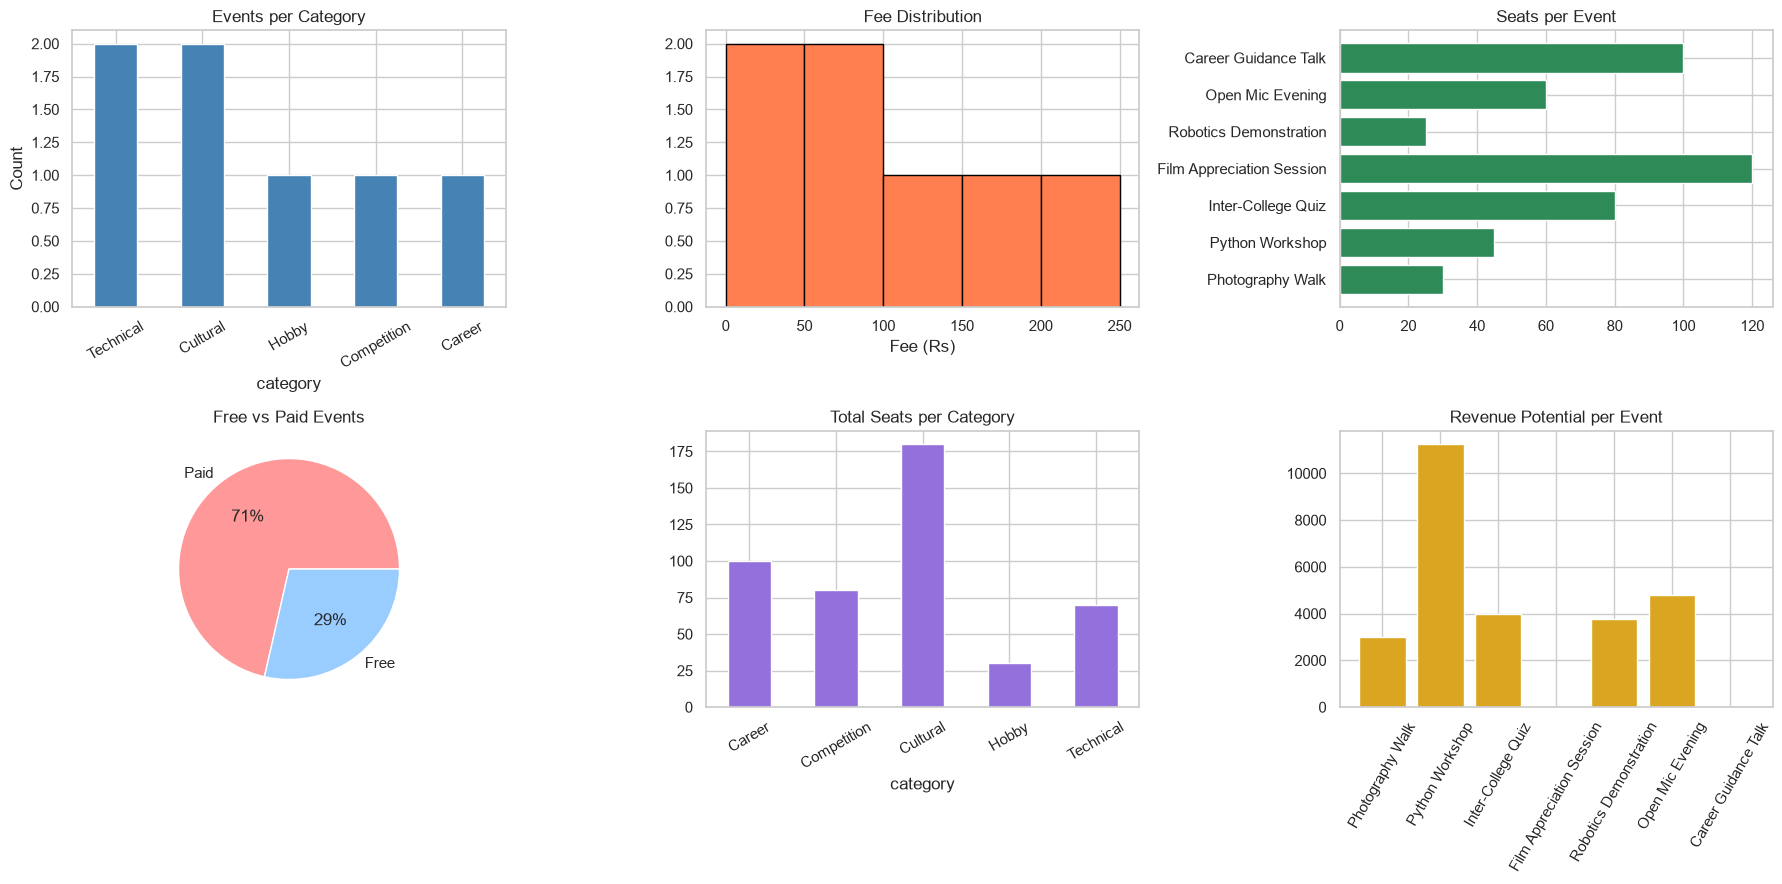

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

# 1. Events per category
df["category"].value_counts().plot(kind="bar", ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Events per Category"); axes[0, 0].set_ylabel("Count")
axes[0, 0].tick_params(axis="x", rotation=30)

# 2. Fee distribution
axes[0, 1].hist(df["fee"], bins=5, color="coral", edgecolor="black")
axes[0, 1].set_title("Fee Distribution"); axes[0, 1].set_xlabel("Fee (Rs)")

# 3. Seats per event
axes[0, 2].barh(df["name"], df["seats"], color="seagreen")
axes[0, 2].set_title("Seats per Event")

# 4. Free vs Paid
df["is_free"].map({True: "Free", False: "Paid"}).value_counts().plot(
    kind="pie", autopct="%1.0f%%", ax=axes[1, 0], colors=["#ff9999", "#99ccff"])
axes[1, 0].set_title("Free vs Paid Events"); axes[1, 0].set_ylabel("")

# 5. Total seats per category
df.groupby("category")["seats"].sum().plot(kind="bar", ax=axes[1, 1], color="mediumpurple")
axes[1, 1].set_title("Total Seats per Category"); axes[1, 1].tick_params(axis="x", rotation=30)

# 6. Revenue potential per event
axes[1, 2].bar(df["name"], df["revenue_potential"], color="goldenrod")
axes[1, 2].set_title("Revenue Potential per Event")
axes[1, 2].tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()

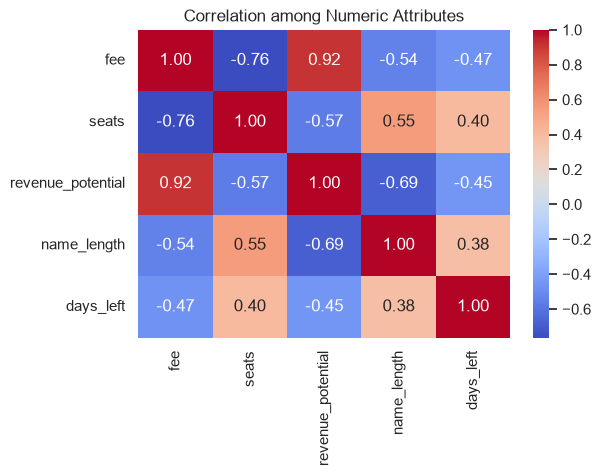

In [19]:
# Correlation heatmap of numeric columns
num_cols = ["fee", "seats", "revenue_potential", "name_length", "days_left"]
plt.figure(figsize=(6, 4))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation among Numeric Attributes")
plt.show()

## 10. Save CSV and summary

In [20]:
df.to_csv("campus_events_clean.csv", index=False, encoding="utf-8-sig")
print("Saved campus_events_clean.csv with shape", df.shape)

Saved campus_events_clean.csv with shape (7, 15)


In [21]:
print("INSIGHTS")
print("1. Total events:", len(df), "| Categories:", df["category"].nunique())
print("2. Most common category:", df["category"].value_counts().idxmax())
print("3. Free events:", int(df["is_free"].sum()), "of", len(df))
print("4. Highest fee:", df.loc[df["fee"].idxmax(), "name"], "at Rs", df["fee"].max())
print("5. Highest revenue potential:", df.loc[df["revenue_potential"].idxmax(), "name"],
      "= Rs", df["revenue_potential"].max())
print("6. Average fee of paid events: Rs", round(df.loc[~df["is_free"], "fee"].mean(), 2))
print("7. Total seats available:", df["seats"].sum())

INSIGHTS
1. Total events: 7 | Categories: 5
2. Most common category: Technical
3. Free events: 2 of 7
4. Highest fee: Python Workshop at Rs 250.0
5. Highest revenue potential: Python Workshop = Rs 11250.0
6. Average fee of paid events: Rs 126.0
7. Total seats available: 460


## Quick revision (exam cheat sheet)
| Task | Code |
|---|---|
| Open file | `BeautifulSoup(open(f), "html.parser")` |
| All blocks | `soup.find_all("div", class_="event")` |
| Safe text | `el.get_text(strip=True) if el else None` |
| Remove symbols | `.str.replace(r"[^\d.]", "", regex=True)` |
| Number from text | `.str.extract(r"(\d+)")[0].astype(int)` |
| Date | `pd.to_datetime(col, format="%d %B %Y")` |
| Missing | `fillna()`, `isnull().sum()` |
| Duplicates | `drop_duplicates()` |
| Min-Max | `(x - x.min()) / (x.max() - x.min())` |